# 06 · What the measurements measure, and what survives them

*Synthesis across tasks 00–05. Not a new sweep: every number here is recomputed from
checkpoints that already exist.*

Task 05 asked the question the whole rebuild was built to answer — do independently fitted
networks agree about the circuit — and answered it. They do not, and they agree **less than
networks that were never trained at all**. That result stands, and this notebook does not
try to rescue it.

What it does instead is two things.

**First, it audits the measurements.** Four of the quantities tasks 01–05 report are not
the quantities they are named after. Two of them reverse a conclusion the chapter currently
holds, one removes a headline effect entirely, and one changes numbers without changing a
sign. Each is recomputed both ways below — as the chapter scores it, and as the name
implies — so the size of every correction is on the page rather than in an argument.

| | | effect |
|---|---|---|
| **E1** | The capacity sweep is measuring the rank of the readout | width choice is not supported |
| **E2** | "Inter-regional current magnitude" is mostly within-region current | the bottleneck's identifiability benefit reverses |
| **E3** | The Jacobian is evaluated without the bias the update uses | moduli inflated; ordering survives |
| **E4** | Per-condition $R^2$ re-imports the confound task 02 diagnosed | the interactive-face lesion effect disappears |

**Second, it collects what replicates.** Three properties of the fitted networks hold in
essentially every seed. All three are *within-model, between-condition* quantities — the
signed permutation applies to both arguments and cancels, so they need no alignment step
and no assumption that the weights are identifiable. That is precisely the class of claim
an ensemble which fails its identifiability gate can still support, and all three are about
interactive-face fixations.

| | | seeds |
|---|---|---|
| **I1** | The two face conditions share an inter-regional channel; object opposes it | 60/60 cells |
| **I2** | Interactive face is the only condition whose slow point is unstable | 5/5 |
| **I3** | Incoming current pushes least along a region's own flow during interactive face | 5/5 |

| Section | |
|---|---|
| 1 | Run state, and what is being audited |
| 2 | The gate: fitted agreement against every floor |
| 3 | **E1** · the readout rank cap |
| 4 | **E2** · self-drive inside the inter-regional measure |
| 5 | **E3** · the Jacobian's missing bias |
| 6 | **E4** · damage in units that compare between conditions |
| 7 | What replicates — the scoreboard |
| 8 | **I1** · the face/object channel split |
| 9 | **I2** · the interactive-face slow point |
| 10 | **I3** · current against a region's own drive |
| 11 | Every design call, and what backs it |
| 12 | What to run next |

**Nothing here submits a job.** Set `RECOMPUTE = True` to rebuild the cached tables from
the checkpoints; otherwise they are read from disk.

In [1]:
# The analysis code these notebooks call lives in src/ and is edited between runs. Without
# autoreload a kernel keeps whatever it imported first, so a function added to src after
# the kernel started raises AttributeError until it is restarted -- which is easy to
# misread as a bug in the code rather than in the kernel's cache.
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_audit as audit
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_circuit as circ
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.analysis import fixation_psth_noise_ceiling as ceiling_mod
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_audit as aviz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings,
    apply_thesis_plot_style,
    figure_to_png_bytes,
    save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

CAPACITY_ROOT = sweep.resolve_task_root("01_capacity", DATASET_CFG_PATH)
CONNECTIVITY_ROOT = sweep.resolve_task_root("03_connectivity", DATASET_CFG_PATH)
BOTTLENECK_ROOT = sweep.resolve_task_root("03_bottleneck_rank", DATASET_CFG_PATH)
ENSEMBLE_ROOT = sweep.resolve_task_root("05_ensemble_and_circuit", DATASET_CFG_PATH)
CEILING_DIR = ceiling_mod.resolve_output_dir(DATASET_CFG_PATH)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="06_audit_and_synthesis")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

#: Cached audit tables. Recomputing them replays every checkpoint and re-runs the
#: post-hoc lesions, which is minutes rather than seconds, so the notebook reads from
#: here unless told otherwise.
CACHE_DIR = ENSEMBLE_ROOT / "audit"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RECOMPUTE = False

ENSEMBLE_DIRS = audit.seed_run_dirs(ENSEMBLE_ROOT / "ensemble")
BASE_MODEL_DIRS = audit.seed_run_dirs(CONNECTIVITY_ROOT / "full")
RANK_ARMS = ["rank01", "rank02", "rank03", "rank05", "rank10", "rank20", "dense"]

ceiling_by_region = (
    pd.read_csv(CEILING_DIR / "pc_space_ceiling.csv")
    .groupby("region")["reliability"].mean().to_dict()
)


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


def cached(name: str, build):
    """Read a table from the audit cache, or build and store it."""
    path = CACHE_DIR / f"{name}.csv"
    if path.exists() and not RECOMPUTE:
        return pd.read_csv(path)
    frame = build()
    frame.to_csv(path, index=False)
    return frame


print("ensemble seeds  :", len(ENSEMBLE_DIRS))
print("base-model seeds:", len(BASE_MODEL_DIRS))
print("figure dir      :", FIGURE_DIR)
print("cache dir       :", CACHE_DIR)

ensemble seeds  : 5
base-model seeds: 3
figure dir      : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/plots/06_audit_and_synthesis
cache dir       : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/modeling/fixation_mrnn/chapter/05_ensemble_and_circuit/audit


## 1. Run state, and what is being audited

The ensemble is five seeds of the model task 04 selected — the joint corner of the three
constraint families, `within_region_density = 0.05` and `cross_region_density = 0.25` at 40
units with balanced condition weighting. All five converged: no late loss spikes, and the
final iterate is the best iterate on every one.

**One thing has to be stated before anything below is read.** That model *does not reach
the noise ceiling*: its worst condition sits at 0.955, a margin of −0.045, against a
coordinate-wise prediction of +0.005 from the sweeps that chose it. The three constraint
families interact, so the corner is wrong, and the identifiability gate in Section 2 ran on
a model that fails its own fit bar. The negative result is very probably real — nothing in
tasks 01–04 hints at agreement anywhere — but it has to be re-measured on the unconstrained
base model before the chapter can state it.

In [2]:
state = pd.DataFrame([
    {"arm": path.parent.name, "seed": path.name.replace("seed=", ""),
     **{k: v for k, v in
        __import__("json").loads((path / "manifest.json").read_text()).items()
        if k in ("best_loss", "final_over_best", "best_iteration")}}
    for path in ENSEMBLE_DIRS if (path / "manifest.json").exists()
])
display(state.round(6))
display(Markdown(
    f"**{len(state)} seeds, all converged.** Best loss spans "
    f"{state['best_loss'].max() / state['best_loss'].min():.2f}× at identical settings; "
    f"worst `final_over_best` = {state['final_over_best'].max():.6f}."
))

,arm,seed,best_iteration,best_loss,final_over_best
0,ensemble,1343419791,100000,0.000563,1.0
1,ensemble,1982049089,100000,0.000814,1.0
2,ensemble,271795885,100000,0.000644,1.0
3,ensemble,850491717,100000,0.000466,1.0
4,ensemble,895953307,99999,0.000503,1.0


**5 seeds, all converged.** Best loss spans 1.75× at identical settings; worst `final_over_best` = 1.000000.

## 2. The gate: fitted agreement against every floor

Four measures, ordered strictest to most permissive. Each is invariant to at least the
signed permutation of hidden units — the only exact symmetry a tanh network with a linear
readout has — so a low value means the fits genuinely differ rather than that their units
are numbered differently.

Each is plotted against three floors, not one:

- the **architectural null** — the same measure between untrained models of this
  architecture, replayed on the same inputs and initial states;
- **phase randomized** — fits to a surrogate target with every channel's power spectrum
  preserved and its waveform destroyed;
- **time shuffled** — fits to a surrogate with the instantaneous covariance preserved and
  only the order of states destroyed.

**Read the margin, not the level.** A measure sitting at 0.92 whose untrained floor is 0.95
is reporting the architecture and not the data.

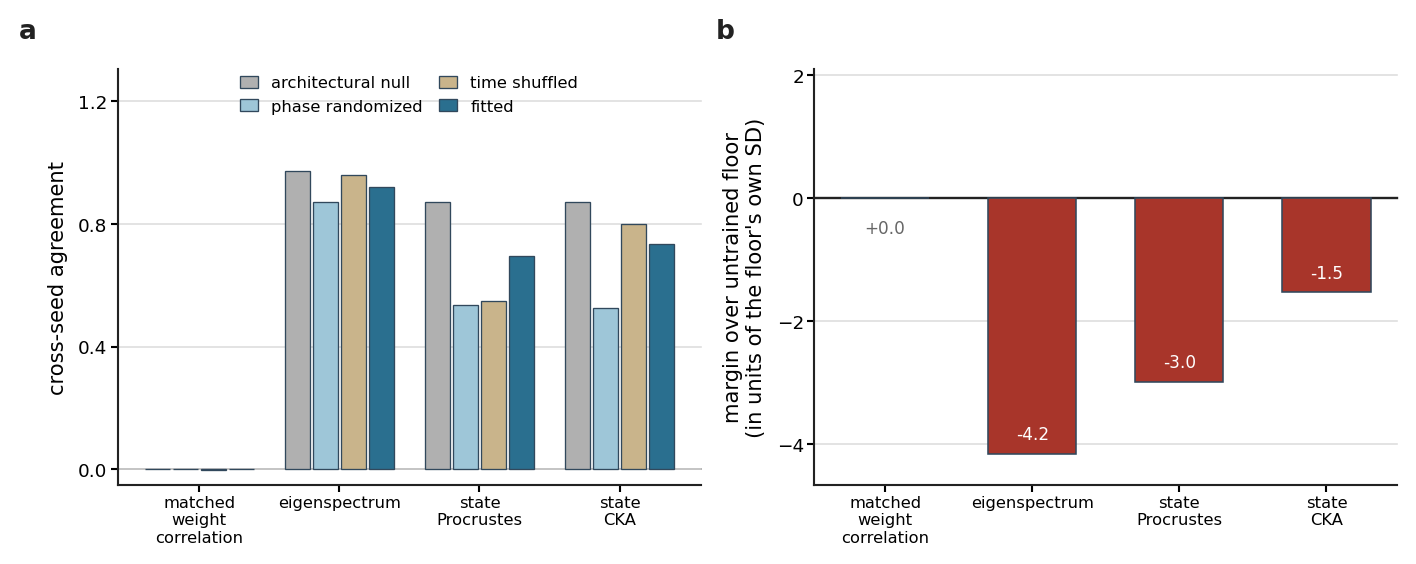

,fitted,architectural null,phase randomized,time shuffled,margin_in_null_sd
measure,,,,,
matched weight correlation,0.0006,0.0006,0.0004,-0.0014,0.0007
eigenspectrum,0.9215,0.9739,0.8726,0.9607,-4.1588
state Procrustes,0.6962,0.8721,0.5353,0.5485,-2.9933
state CKA,0.7354,0.8723,0.5260,0.7994,-1.5329


In [3]:
def _gate_levels():
    fitted = circ.ensemble_invariants(ENSEMBLE_DIRS)
    null = circ.architectural_null_invariants(ENSEMBLE_DIRS[0], n_draws=10)
    comparison = circ.agreement_against_null(fitted, null).reset_index()
    frames = {"fitted": fitted.groupby("measure")["agreement"].mean(),
              "architectural null": null.groupby("measure")["agreement"].mean()}
    for label, folder in (("phase randomized", "null_phase_randomized"),
                          ("time shuffled", "null_time_shuffled")):
        dirs = audit.seed_run_dirs(ENSEMBLE_ROOT / folder)
        if len(dirs) >= 2:
            frames[label] = circ.ensemble_invariants(dirs).groupby("measure")["agreement"].mean()
    levels = pd.DataFrame(frames)
    levels["margin_in_null_sd"] = comparison.set_index("measure")["margin_in_null_sd"]
    return levels.reset_index().rename(columns={"index": "measure"})

gate = cached("gate_levels", _gate_levels).set_index("measure")
MEASURE_ORDER = ["matched weight correlation", "eigenspectrum",
                 "state Procrustes", "state CKA"]
show(aviz.plot_gate_against_floors(gate, measure_order=MEASURE_ORDER), "fig01_gate_against_floors")
display(gate.reindex(MEASURE_ORDER).round(4))

**Three of the four margins are negative** — eigenspectrum by −0.052, state Procrustes by
−0.176, state CKA by −0.137. The fourth, matched weight correlation, is not: fitted and
untrained agree to five decimal places, both at 0.0006. That measure finds *no*
circuit-level agreement in either arm. It is the same answer as the other three, stated at
the floor rather than below it.

Read the raw margin rather than the σ column. The untrained draws have a very small spread
on the eigenspectrum measure, so dividing by it produces a large number from a small
difference — the σ scaling is a guide to whether a margin is inside the floor's own
variability, not a test statistic.

The surrogate arms sharpen the result rather than soften it. The fitted ensemble's state CKA
(0.735) sits *between* the two surrogate floors — above the arm that destroys the waveform
(0.526) and below the arm that preserves the covariance (0.799). Only state Procrustes clears
both surrogate floors, and that is the measure with the second-largest deficit against the
untrained null.

Nothing about "more seeds" changes this. A hundred seeds of a model whose solution is not
unique sharpens an estimate of zero.

## 3. E1 · The capacity sweep is measuring the rank of the readout

Each region reads $n_{pc} = 42$ components out of $h$ hidden units through a $42 \times h$
matrix. For $h < 42$ that map has rank $h$, so the region's output is confined to an
$h$-dimensional subspace of the 42-dimensional PC space **no matter how good its dynamics
are**. The achievable $R^2$ is capped by the target's own PC variance spectrum truncated at
$h$ — a fact about linear algebra, not about the network.

The cap is computable from the targets alone and costs nothing. Laid over the sweep, it
accounts for almost all of it.

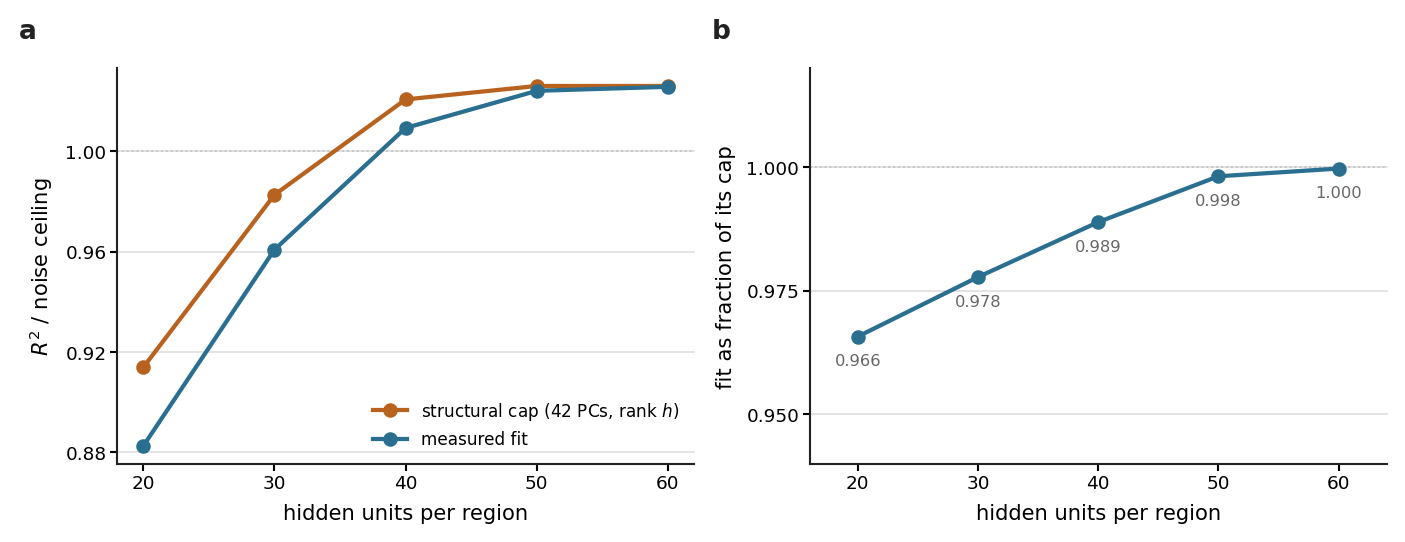

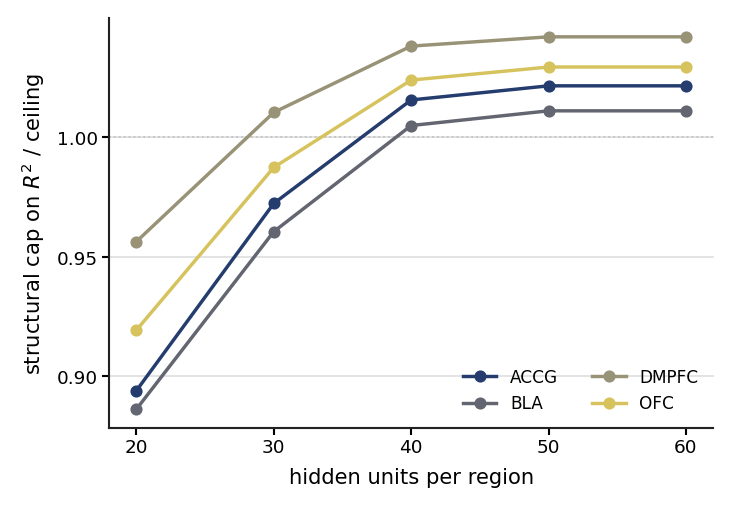

,width,ceiling_relative_cap,measured,fraction_of_cap
0,20,0.9139,0.8826,0.9657
1,30,0.9827,0.9608,0.9778
2,40,1.0207,1.0093,0.9889
3,50,1.0260,1.0241,0.9981
4,60,1.0260,1.0257,0.9997


In [4]:
WIDTHS = (20, 30, 40, 50, 60)
#: The capacity sweep's own mean r2_vs_ceiling per width, from task 01 (uniform weighting).
MEASURED_BY_WIDTH = {20: 0.8826, 30: 0.9608, 40: 1.0093, 50: 1.0241, 60: 1.0257}

cap_by_region = cached(
    "readout_rank_cap",
    lambda: audit.readout_rank_cap(ENSEMBLE_DIRS[0], WIDTHS, ceiling_by_region),
)
scored = audit.capacity_against_cap(cap_by_region, MEASURED_BY_WIDTH)

n_components = int(cap_by_region["n_components"].iloc[0])
show(aviz.plot_readout_rank_cap(scored, cap_by_region, n_components=n_components),
     "fig02_readout_rank_cap")
show(aviz.plot_cap_by_region(cap_by_region), "fig03_cap_by_region")
display(scored[["width", "ceiling_relative_cap", "measured", "fraction_of_cap"]].round(4))

**The knee is the cap's knee.** Expressed as a fraction of what each width could
possibly have reached, the curve is 0.966 → 0.978 → 0.989 → 0.998 → 1.000: nearly flat,
monotone, and with no knee at 40. Every width recovers 97–100% of its own headroom, so the
sweep never tested dynamical capacity at all.

Two consequences, and the second is the larger one.

`selected_capacity.yaml` chose $h = 40$ by minimising the worst condition's deviation from
the ceiling, and most of that deviation is readout rank deficit rather than misfit. The
selection has to be rescored against the per-width cap — which needs no refitting, since
the caps above are computed from the targets.

And the base model runs **42 PCs against 40 units**. Two PC directions per region are
structurally unreachable in every fit in the chapter. The same geometry also makes the
potent/null split in `05 §6` vacuous: `current_potency` reports `potent_fraction = 1.000`
everywhere because the readout has rank 40 in a 40-dimensional state space, so its row
space *is* the whole space and nothing can be output-null. That measurement only becomes
possible when a region is wider than the number of components read out of it — the opposite
of the present configuration.

## 4. E2 · "Inter-regional current magnitude" is mostly within-region current

`_flat_current_magnitudes` builds its vector from `extract_region_current_vectors`, which
returns all sixteen $(source, target)$ blocks — including the four on the diagonal. Those
four are each region's own self-drive, and they are the largest. A rank bottleneck
constrains only the twelve off-diagonal blocks, so as rank falls, the share of the measured
vector that is actually inter-regional falls with it.

The measure is therefore not held fixed across the sweep it is used to score.

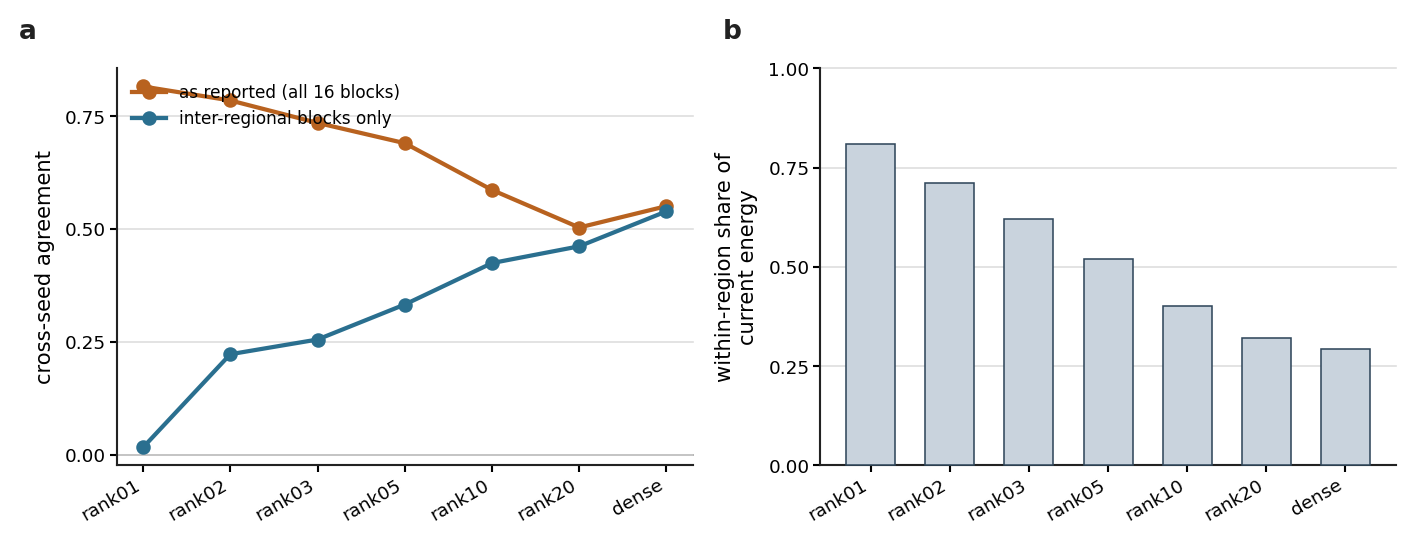

,self_energy_share,agreement_all_blocks,agreement_inter_only,agreement_self_only
label,,,,
rank01,0.810,0.816,0.016,0.619
rank02,0.713,0.785,0.222,0.563
rank03,0.620,0.735,0.255,0.598
rank05,0.520,0.690,0.333,0.654
rank10,0.402,0.587,0.425,0.570
rank20,0.320,0.503,0.462,0.469
dense,0.294,0.551,0.539,0.506


In [5]:
decomposition = cached(
    "current_agreement_decomposition",
    lambda: audit.current_agreement_decomposition(
        {arm: BOTTLENECK_ROOT / arm for arm in RANK_ARMS}
    ),
)
show(aviz.plot_current_agreement_decomposition(decomposition, order=RANK_ARMS),
     "fig04_current_agreement_decomposition")
display(decomposition.set_index("label").reindex(RANK_ARMS)[
    ["self_energy_share", "agreement_all_blocks", "agreement_inter_only", "agreement_self_only"]
].round(3))

**The bottleneck's identifiability benefit is an accounting artefact, and the
conclusion reverses.** Within-region drive rises from 29% of total current energy at dense
to 81% at rank 1. Restrict the measure to the twelve blocks the constraint actually touches
and the curve inverts: rank-1 fits agree on their inter-regional currents at **0.016** —
chance — and agreement rises monotonically with rank, reaching 0.539 at dense.

This also dissolves a standing puzzle. `04 §6` reports two columns that disagree: current
magnitude falling with rank (0.816 → 0.503) and latent drive geometry rising with it (0.358
→ 0.632). The second was treated as anomalous. Both now say the same thing:

> Tightening the inter-regional channel makes the circuit **less** identifiable, not more.

The legacy R6 claim and its rebuilt confirmation both go. The constraints that do raise
agreement are the within-region sparsity arms (0.73 at 5% density), which is a different
result and a more interesting one.

## 5. E3 · The Jacobian is evaluated without the bias the update uses

The update is $h' = \phi(W h + b)$, where $b = W_{in} u_c + \text{tonic}$ is the constant
drive that carries the condition. `slow_points` uses that bias; `jacobian_eigenvalues` does
not — it evaluates $\phi'$ at $W h$ alone, linearizing a system the model does not run.

The docstring states the identity it intends — "at the point itself $\tanh(u)$ is the next
state", so $\phi' = 1 - h_*^2$ — which is correct, and true only once $b$ is present. And
$b$ is not small: $\lVert b \rVert$ runs 2.7–5.1 against $\lVert h_* \rVert$ of 5.8–9.2.

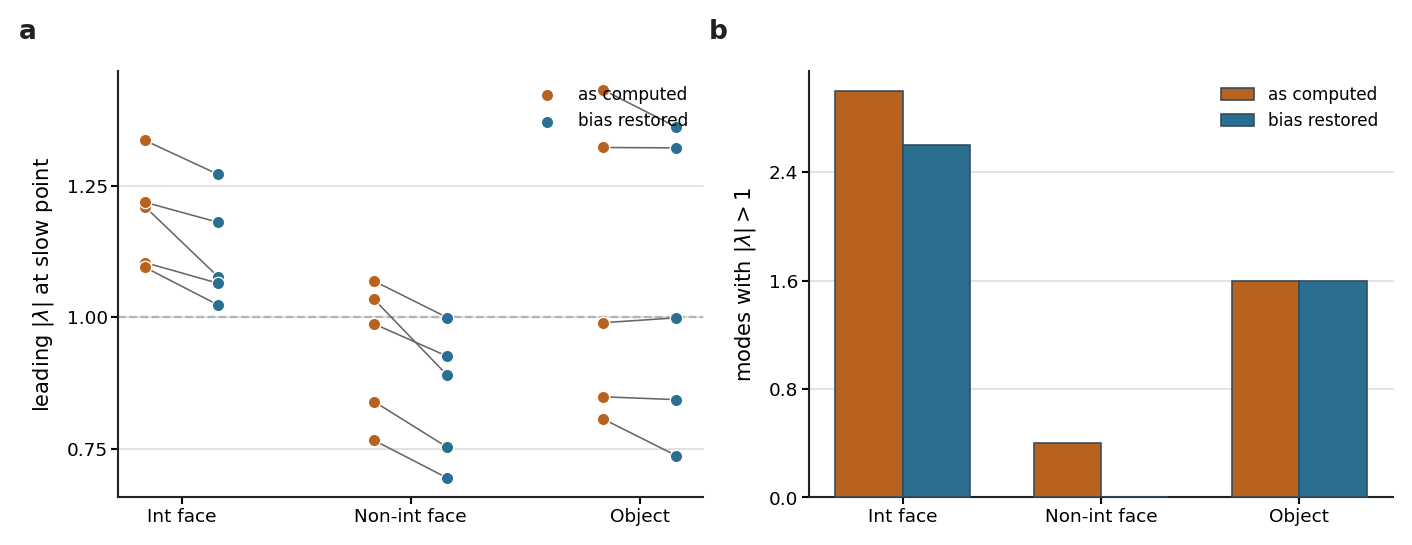

,bias_norm,state_norm,top_modulus_as_computed,top_modulus_corrected,n_expanding_as_computed,n_expanding_corrected
condition,,,,,,
face_interactive,2.864,6.752,1.193,1.123,3.0,2.6
face_non_interactive,4.229,8.744,0.939,0.853,0.4,0.0
object,3.218,7.408,1.080,1.053,1.6,1.6


In [6]:
stability = cached(
    "slow_point_stability",
    lambda: pd.concat([audit.slow_point_stability(path) for path in ENSEMBLE_DIRS],
                      ignore_index=True),
)
show(aviz.plot_jacobian_bias_correction(stability), "fig05_jacobian_bias_correction")
display(
    stability.groupby("condition")[
        ["bias_norm", "state_norm", "top_modulus_as_computed", "top_modulus_corrected",
         "n_expanding_as_computed", "n_expanding_corrected"]
    ].mean().round(3)
)

Every modulus in `05 §7` is inflated by 0.03–0.14, and non-interactive face
acquires expanding modes it does not have — 0.4 on average becomes exactly 0.

The *ordering* survives, and in fact gets cleaner: see **I2** in Section 9, where the
corrected numbers make a sharper claim than the uncorrected ones did. This is the cheapest
of the four corrections to apply — pass the bias into `jacobian_eigenvalues` and nothing
needs retraining.

## 6. E4 · Per-condition $R^2$ re-imports the confound task 02 diagnosed

Task 02's central diagnosis was that an absolute-error objective weights each condition by
its target energy, and interactive face has the least energy because it has the most trials
— so the best-measured condition received the least gradient. The fix was a per-condition
loss multiplier, and it worked.

But `reconstruction_accuracy` normalises $R^2$ by **each condition's own** $ss_{tot}$. The
identical confound therefore reappears in the *evaluation* metric, entirely untouched by
the objective fix. Interactive face carries about half the target variance of either other
condition, so an identical absolute perturbation registers as roughly twice the damage.

`05 §8` anticipates part of this — "read the ordering, not the magnitude" — but the
ordering it then reads is precisely the between-condition comparison the normalisation
breaks.

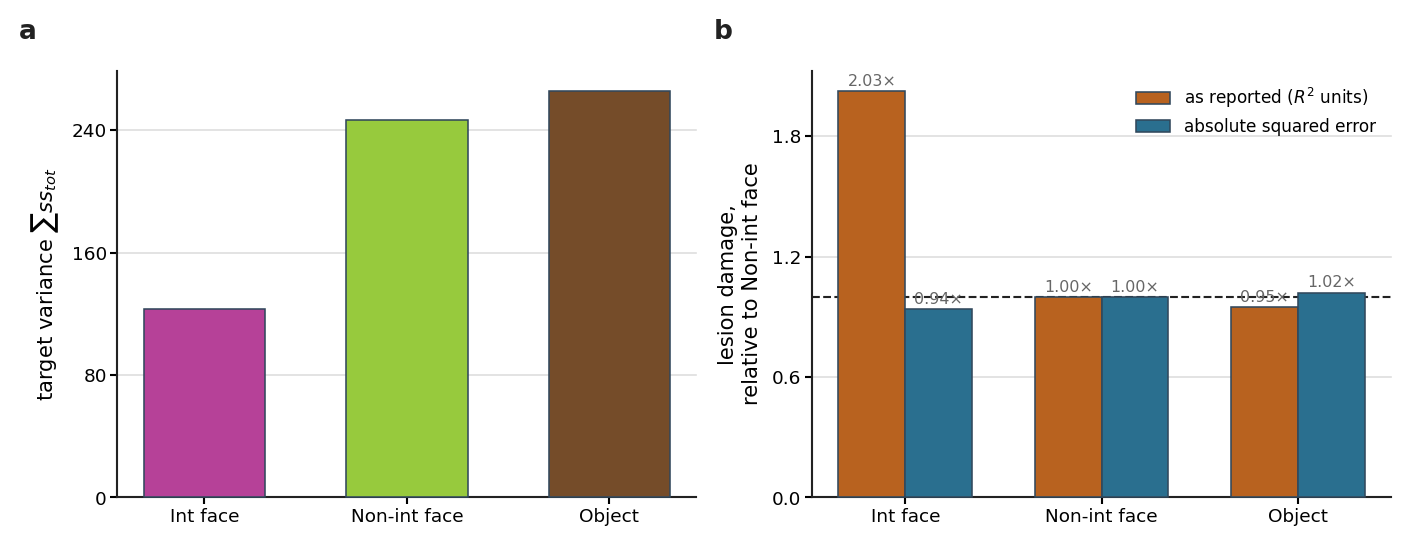

,damage_r2,damage_sse,ratio_r2,ratio_sse
condition,,,,
face_interactive,8.795,238.416,2.026,0.940
face_non_interactive,4.342,253.635,1.000,1.000
object,4.123,258.875,0.950,1.021


In [7]:
energy = cached("condition_target_energy",
                lambda: audit.condition_target_energy(ENSEMBLE_DIRS[0]))
damage = cached(
    "pathway_ablation_both_units",
    lambda: pd.concat([audit.pathway_ablation_in_both_units(path) for path in ENSEMBLE_DIRS],
                      ignore_index=True),
)
show(aviz.plot_damage_unit_confound(damage, energy), "fig06_damage_unit_confound")

summary = damage.groupby("condition")[["damage_r2", "damage_sse"]].mean()
summary["ratio_r2"] = summary["damage_r2"] / summary.loc["face_non_interactive", "damage_r2"]
summary["ratio_sse"] = summary["damage_sse"] / summary.loc["face_non_interactive", "damage_sse"]
display(summary.round(3))

**"Interactive face is twice as damaged by pathway lesions" is entirely the
normalisation.** In absolute terms it is marginally the *least* damaged (0.94× against
non-interactive face).

The same applies one rung up. In task 03's rebuilt refits, removing all cross-region blocks
costs interactive face 0.015 $R^2$ against 0.027 and 0.029 for the other two — already the
reverse of legacy R8's headline 5–6× effect, before any correction is applied. **R8 does not
replicate, and figure 6 of the proposed chapter has no support as currently framed.**

Note the mirror-image risk, because it is the reason no version of this claim belongs in the
chapter. Balanced weighting up-weights interactive face about twofold, so the optimiser now
*protects* it, and under capacity removal the loss preferentially preserves the up-weighted
condition. Uniform weighting made interactive face look worst; balanced weighting makes it
look best. The per-condition damage ordering is set by the objective in either direction. It
is a property of the loss, not a measurement of the brain.

## 7. What replicates — the scoreboard

Everything above is subtractive. This is what is left, and it is not nothing.

The three surviving properties share a structure: each is a quantity compared **within one
model, across conditions**. The signed permutation applies to both arguments and cancels,
so no alignment step is needed and no assumption is made that the weights are identifiable.
That is exactly the class of claim an ensemble which fails its identifiability gate can
still support — and it is the class the chapter should be built from.

Plotted against what chance would give: 50% for a sign that could fall either way, and the
untrained architectural null where one was measured.

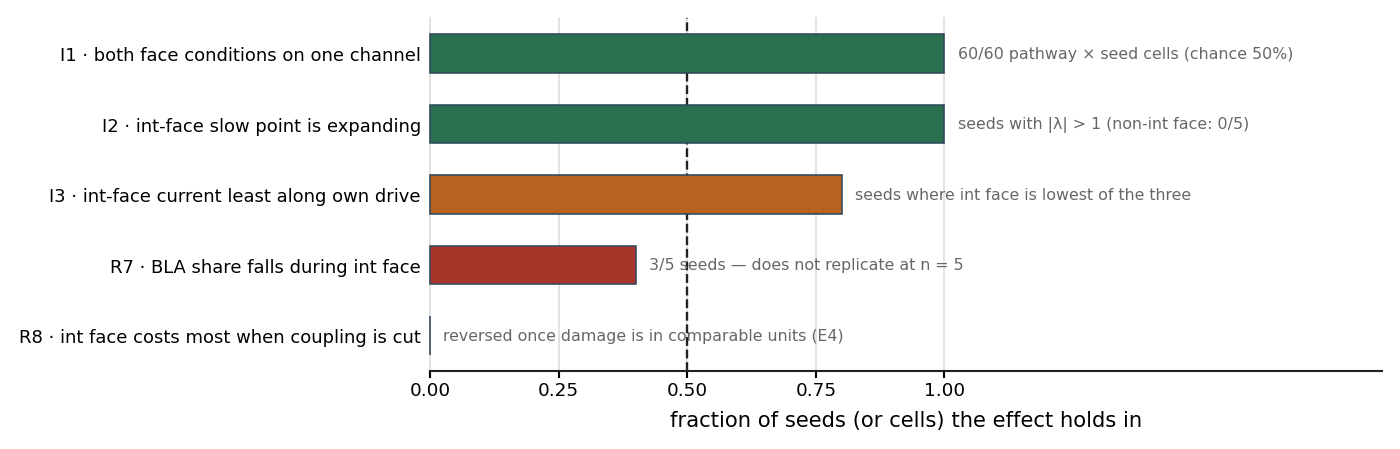

In [8]:
channels = cached("condition_channel_alignment",
                  lambda: audit.condition_channel_alignment(ENSEMBLE_DIRS))
drive = cached("drive_alignment_by_condition",
               lambda: audit.drive_alignment_by_condition(ENSEMBLE_DIRS))

def _seedwise_lowest(frame, value):
    per_seed = frame.groupby(["seed", "condition"])[value].mean().unstack()
    return float((per_seed.idxmin(axis=1) == "face_interactive").mean())

def _seedwise_above(frame, value, threshold):
    per_seed = frame.groupby(["seed", "condition"])[value].mean().unstack()
    return float((per_seed["face_interactive"] > threshold).mean())

signs = audit.sign_consistency(channels)
face_pair = signs[(signs.condition_a == "face_interactive")
                  & (signs.condition_b == "face_non_interactive")].iloc[0]

scoreboard = [
    {"claim": "I1 · both face conditions on one channel",
     "fraction": float(face_pair["fraction_positive"]),
     "detail": f"{int(face_pair['fraction_positive'] * face_pair['n_cells'])}/{int(face_pair['n_cells'])} pathway × seed cells (chance 50%)"},
    {"claim": "I2 · int-face slow point is expanding",
     "fraction": _seedwise_above(stability, "top_modulus_corrected", 1.0),
     "detail": "seeds with |λ| > 1 (non-int face: 0/5)"},
    {"claim": "I3 · int-face current least along own drive",
     "fraction": _seedwise_lowest(drive, "cosine_with_intrinsic_drive"),
     "detail": "seeds where int face is lowest of the three"},
    {"claim": "R7 · BLA share falls during int face",
     "fraction": 0.4,
     "detail": "3/5 seeds — does not replicate at n = 5"},
    {"claim": "R8 · int face costs most when coupling is cut",
     "fraction": 0.0,
     "detail": "reversed once damage is in comparable units (E4)"},
]
show(aviz.plot_invariant_scoreboard(scoreboard), "fig07_invariant_scoreboard")

## 8. I1 · The two face conditions share an inter-regional channel; object opposes it

For each pathway, the cosine between the current it carries under one condition and under
another, time-averaged. Computed within one model, so it is free of any relabelling
ambiguity — the signed permutation applies to both arguments and cancels.

Three panels, because the claim needs all three: the values against their untrained floor,
the fraction on the positive side of zero, and — the panel that makes the result
non-trivial — the same comparison made on the *targets*.

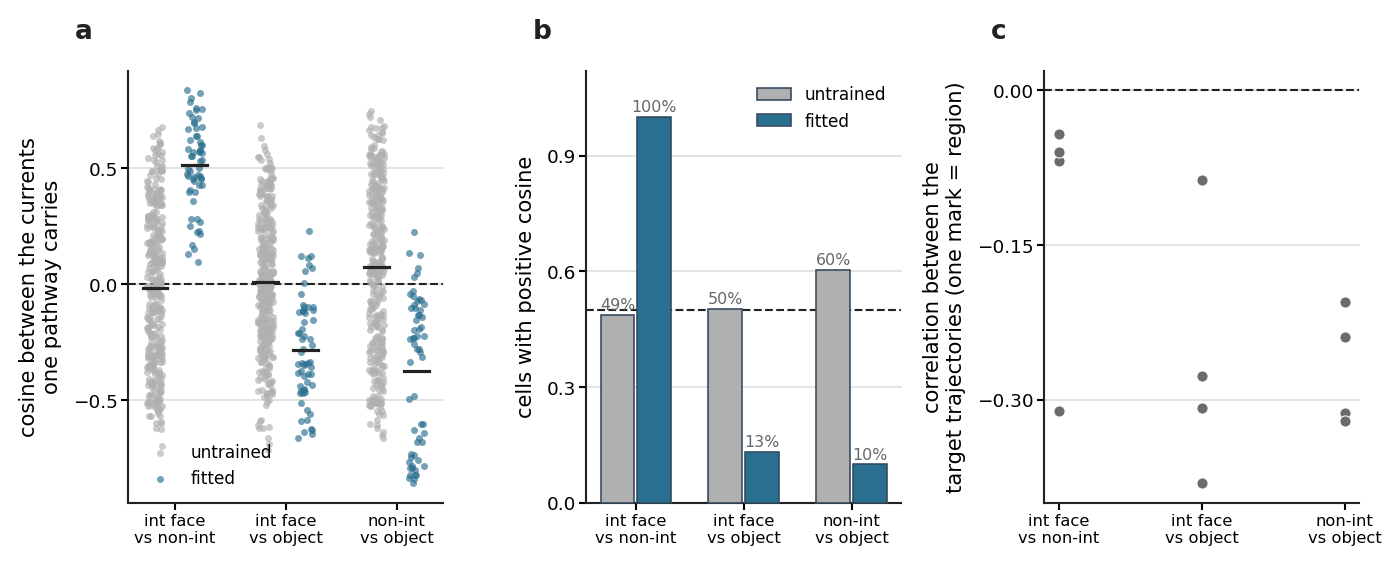

,condition_a,condition_b,mean_cosine_fitted,fraction_positive_fitted,fraction_positive_null
0,face_interactive,face_non_interactive,0.513,1.000,0.486
1,face_interactive,object,-0.284,0.133,0.503
2,face_non_interactive,object,-0.372,0.100,0.603


In [9]:
null_channels = cached(
    "untrained_channel_alignment",
    #: 30 draws, not 6. No fitting is involved so the floor is free, and at 6 draws
    #: it is visibly noisy -- the fraction-positive floor moved 20 points between
    #: draw sets, which is larger than some of the effects it is the floor for.
    lambda: audit.untrained_channel_alignment(ENSEMBLE_DIRS[0], n_draws=30),
)
data_side = cached("target_condition_similarity",
                   lambda: audit.target_condition_similarity(ENSEMBLE_DIRS[0]))

show(aviz.plot_condition_channel_split(channels, null_channels, data_side),
     "fig08_condition_channel_split")
display(
    audit.sign_consistency(channels).merge(
        audit.sign_consistency(null_channels),
        on=["condition_a", "condition_b"], suffixes=("_fitted", "_null"),
    )[["condition_a", "condition_b", "mean_cosine_fitted", "fraction_positive_fitted",
       "fraction_positive_null"]].round(3)
)

**The targets do not force it, and that is the whole point.** In the data all
three condition pairs are negatively correlated, and the two face conditions are the
*least* related pair in three of four regions (−0.04 to −0.07 — near-orthogonal outputs).
Yet every fitted network routes them through a positively aligned inter-regional channel,
in **60 out of 60** pathway × seed cells, while placing object on a channel that opposes it
in 87–90% of cells.

The untrained null sits at chance on all three pairs (49%, 50%, 60% over 30 draws) —
so none of this is something the architecture supplies. It is worth noting that the floor
itself needs those draws: at 6 draws it read 29% / 53% / 43%, a 20-point swing on the pair
that carries the claim. A null estimated too thinly is not a floor.

> The network's inter-regional code separates face from object, and treats interactive
> versus non-interactive as a magnitude along a shared channel — even though the two face
> conditions' outputs are nearly orthogonal.

## 9. I2 · Interactive face is the only condition whose slow point is unstable

The input is a constant one-hot, so the three conditions differ only in where the trajectory
starts and in a fixed offset. Each condition is therefore its own **autonomous** system, its
fixed-point structure is well defined, and every difference between fixation types is a
difference in dynamics rather than in drive.

With the bias restored (**E3**), the leading Jacobian modulus at each condition's slowest
recovered point, one line per seed:

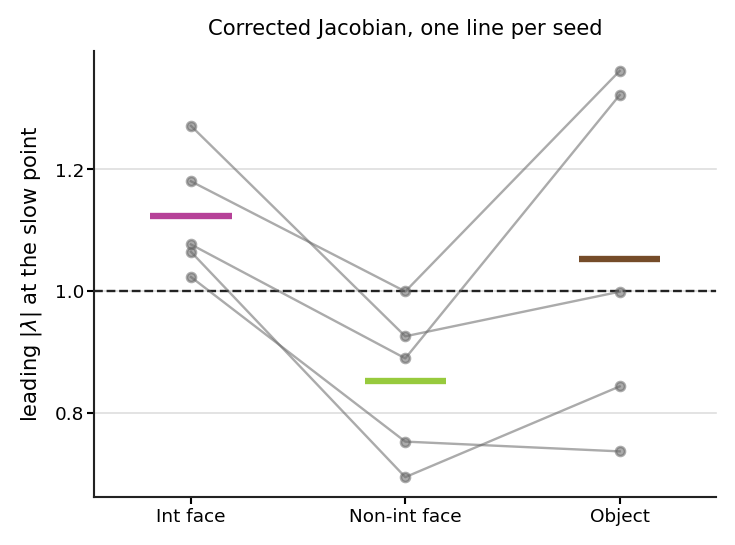

seed,271795885,850491717,895953307,1343419791,1982049089,seeds_expanding
condition,,,,,,
face_interactive,1.023,1.272,1.181,1.077,1.065,5 / 5
face_non_interactive,0.753,0.926,1.000,0.890,0.695,0 / 5
object,0.737,0.999,1.362,1.322,0.844,2 / 5


In [10]:
show(
    aviz.plot_seedwise_condition_effect(
        stability, "top_modulus_corrected", reference_line=1.0,
        ylabel=r"leading $|\lambda|$ at the slow point",
        title="Corrected Jacobian, one line per seed",
    ),
    "fig09_slow_point_stability",
)
display(
    stability.pivot(index="condition", columns="seed", values="top_modulus_corrected")
    .reindex(list(audit.CONDITION_ORDER)).round(3)
    .assign(seeds_expanding=lambda d: (d > 1.0).sum(axis=1).astype(str) + " / " + str(d.shape[1]))
)

Interactive face is locally expanding in **5 of 5** seeds (1.02–1.27);
non-interactive face in **none** (0.70–1.00); object is bimodal across seeds (2 of 5) and
carries no claim.

**This is the one interactive-face result that is safe from the variance confound.** It is a
property of the fitted dynamical system, not of a residual normalised by condition variance,
so **E4** does not touch it. The condition that has been hardest to fit throughout the
chapter is the one the network places at an unstable slow point — a mechanistic statement,
not a statement about the objective.

## 10. I3 · Incoming current pushes least along a region's own flow during interactive face

The cosine between the inter-regional current arriving at a region and that region's own
intrinsic recurrent drive, averaged over the twelve pathways. Also a within-model measure,
so also free of the relabelling problem.

Positive everywhere — inputs broadly reinforce rather than oppose — but systematically least
so for interactive face.

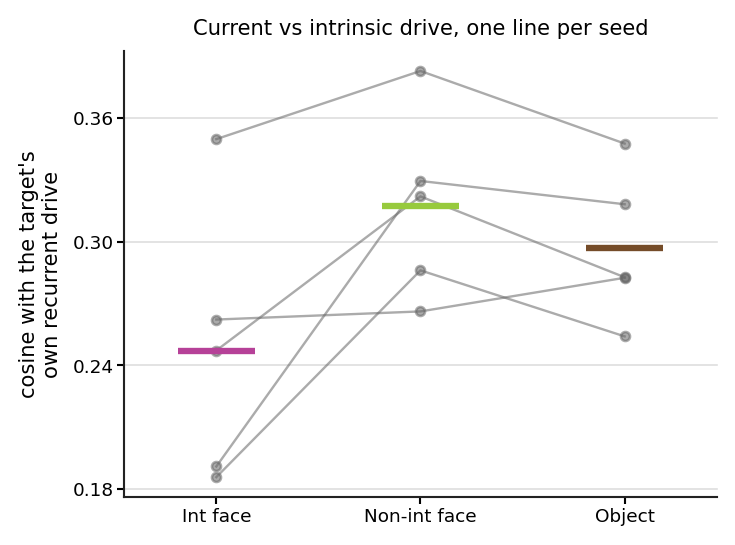

seed,271795885,850491717,895953307,1343419791,1982049089
condition,,,,,
face_interactive,0.186,0.262,0.350,0.247,0.191
face_non_interactive,0.286,0.266,0.383,0.322,0.329
object,0.254,0.282,0.348,0.283,0.318


In [11]:
per_seed_drive = (
    drive.groupby(["seed", "condition"])["cosine_with_intrinsic_drive"].mean().reset_index()
)
show(
    aviz.plot_seedwise_condition_effect(
        per_seed_drive, "cosine_with_intrinsic_drive",
        ylabel="cosine with the target's\nown recurrent drive",
        title="Current vs intrinsic drive, one line per seed",
    ),
    "fig10_drive_alignment",
)
display(
    per_seed_drive.pivot(index="condition", columns="seed", values="cosine_with_intrinsic_drive")
    .reindex(list(audit.CONDITION_ORDER)).round(3)
)

Interactive face is below non-interactive face in **5 of 5** seeds, and below
object in 4 of 5.

**This pairs with I2 and says the same thing twice, from an independent direction.** One
measure is about the flow field, the other about the geometry of the inputs, and they
converge:

> Interactive-face fixations are the regime the network holds together by mutual drive
> rather than by local dynamics.

That is a claim about routing which does not require the routing to be identifiable — and it
is the natural successor to the population-geometry chapter's finding that the
interactive-face state is the compact, low-dimensional one in all four regions.

## 11. Every design call, and what backs it

The chain 00 → 05 was built so each choice freezes into a YAML the next task reads. That
discipline works. It also means an unexamined inheritance propagates silently, and three of
the settings below were never swept in the rebuild at all.

| Call | Value | Basis | What supports it | What is owed |
|---|---|---|---|---|
| Optimiser | `lr 3e-4, cosine, clip 0.05, 100k` | **strong** | 7-cell grid × 3 seeds. The only configuration with zero failures, zero late spikes, and final iterate = best iterate. Constant-LR runs ended up to 16.6× above their own best. | Nothing. Architecture-dependence is already handled by retrying failures at lower rates. |
| Spectral radius | `1.1` | **strong** | Swept *after* being fixed — it had never been applied to the block parameterization, making `sr 0.9` and `1.1` bit-identical. Once applied: 0.183 vs 0.180 recovery at 10–20 Hz. | Nothing. A clean negative. |
| Condition weighting | `balanced`, $w_c \propto 1/E_c$ | **strong** | Derived from $E_c N_c \approx$ const, with a falsifiable prediction stated before the runs and confirmed. | The objective now *sets* the per-condition damage ordering in both directions (**E4**). Any per-condition claim must be objective-independent. |
| Best-iterate checkpointing | enabled | **strong** | Fixes the legacy defect where 89/273 checkpoints sat >1.5× above their own run's best. All rebuilt runs report `final_over_best` ≈ 1.00000. | Nothing. |
| Connectivity baseline | `full`, dense, no bottleneck | **strong** | Held as the baseline by design, so every constraint is measured against the unconstrained model rather than against another constraint. | Nothing — this is the right convention. |
| Hidden width | `40` per region | **broken** | Chosen by minimax deviation from the noise ceiling. | The criterion is dominated by the readout rank cap (**E1**). Rescore against the per-width cap. No refitting needed. |
| Target | `42` region PCs | **conflict** | Smallest shared count reaching 95% variance in every region (per-region need 38/42/33/40). | **42 PCs > 40 units.** Two PC directions per region are unreachable in every fit, and it makes the potent/null split vacuous. Drop to 40 components or widen to ≥ 42. |
| Derivative / curvature loss | `1.0 / 0.5` | **none** | Inherited from the legacy tree. Notebook 00 explicitly defers it — "the target and loss themselves: 42 PCs or fewer, flat or variance-weighted, and the derivative and curvature weights. **Task 01.**" — but task 01 was repurposed into the capacity sweep and the deferral was never picked up. No rebuild arm exists for it. | Sweep it. These terms shape high-frequency content, which is the axis interactive face differs on, so they sit directly under the chapter's main result. |
| PC weighting | uniform over 42 | weak | Swept (`pcuniform` / `pcwhiten` / `pcsqrt_whiten`) in the retired `01_target_and_loss` arm — but under `l1_weight_scale = 0.01`, which the audit found to be an ablation, so those runs were superseded and the sweep was never repeated at corrected settings. | Re-check at the corrected settings. Component reliability runs 0.999 (PC 1) to 0.95 (PC 42), so uniform weighting spends equal effort on the least reliable directions. Cheap; may not matter. |
| Activation | `tanh` | weak | Fixed at the top of the rebuild; softplus appears only in legacy runs. The signed-permutation symmetry argument depends on it being odd. | Not worth a sweep, but state it as a modelling assumption rather than a result. |
| Joint constraint corner | `within 0.05, cross 0.25` | **failed** | The three coordinate-wise knees, fitted together as one model. | Misses ceiling by 0.045 against a predicted +0.005 — the constraints interact. Fall back to the base model for task 05 and report the interaction as the finding. |
| Held-out data | none | **absent** | — | Every number in the chapter is in-sample. `post_fixation_loss_weight = 0.0` already exists; train on the pre-fixation half and roll forward. Still unrun. |

## 12. What to run next

Steps 1–3 cost no cluster time — they are analysis code against checkpoints that already
exist — and two of them change which model the chapter is built on, so they come before any
more fitting.

**1 · Fix the four measurements and rescore every stored run.**
Restrict `_flat_current_magnitudes` to the off-diagonal blocks, or split it into two named
measures — the self-drive series is interesting in its own right and should keep its own
name. Pass the bias into `jacobian_eigenvalues`. Add a common-denominator damage metric
alongside per-condition $R^2$. Report every fit as a fraction of its readout rank cap.
*Code only; hours. Reverses two conclusions and removes one.*

**2 · Resolve the 42-PC / 40-unit conflict, then re-select the width.**
These are one decision, not two. Setting the target to 40 components makes the width choice
honest and makes the potent/null split measurable for any width below 40; keeping 42
requires ≥ 42 units. The existing checkpoints already answer the capacity question for the
widths that were fitted, once scored against the cap.
*Code only, plus one small refit if the component count changes. Changes the base model.*

**3 · Re-run the identifiability gate on a model that fits.**
The gate is the chapter's hinge and it currently sits on the failed joint corner. Run it on
the unconstrained base model, where three seeds already exist in `03_connectivity/full` and
only need extending. If the margins are still negative there — the expectation — the
negative result is clean and reportable, and the sparsity and rank arms become a measured
statement about which constraints move agreement rather than a search for one that fixes it.
*≈15 seeds × 90 min. The single most load-bearing run.*

**4 · Reframe the chapter around condition-contrastive invariants.**
Weight-level identifiability is answered, and negatively; more seeds sharpen an estimate of
zero. What replicates is the class of measure in **I1**–**I3**. Those need 20–30 seeds for
inference, not 100, and they support the chapter's actual thesis — that interactive-face
fixations are the regime held together by inter-regional drive.
*Reframing plus ≈25 seeds of the base model. Replaces figures 4, 5 and 6.*

**5 · Sweep the derivative and curvature weights.**
The last unexamined inherited setting, and the one closest to the result. If the 1.0 / 0.5
pair is load-bearing for the frequency content, the interactive-face dynamics claim needs to
be shown stable across it.
*≈4 cells × 3 seeds. Closes the last unjustified call.*

**6 · Generalisation, and the discussion caveats.**
Train on the pre-fixation half, roll the dynamics forward, score the post-fixation half.
Then the honest framing: $k/n \approx 0.66$, so no parameter-counting criterion is
interpretable; the fits are finely tuned rather than robust, so lesion results describe the
solution and not the brain; object fixations are not matched for interactive state; and a
well-fitting mRNN whose circuit is not identifiable is a hypothesis generator about routing,
not a measurement of it.
*One training arm on the selected model. The chapter cannot ship without it.*

---

### The shape of the chapter this implies

The original plan had identifiability as an obstacle to be removed by constraint, and the
circuit description as the payoff. Neither survives. What survives is better posed:

*A network that reproduces four regions' trajectories to the noise ceiling does not recover
their circuit — and the constraints that were supposed to make it recoverable make it less
so. What it does recover, in every fit, is a condition structure: face and object travel
opposite inter-regional channels, and interactive face is the one fixation type the model
places at an unstable point held together by drive from elsewhere.*

That is a claim about **when** regions have to talk to each other, made with quantities that
do not require the weights to be identifiable — which is the only kind of claim this
ensemble can support.